[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/harshuljain13/llm-inference-at-scale/blob/master/content/00_transformer_at_inference_time/00.4_why_llm_inference_is_different/lab.ipynb) [![Open In Molab](https://img.shields.io/badge/Open%20in-Molab-blue)](https://molab.marimo.io/github/harshuljain13/llm-inference-at-scale/blob/master/content/00_transformer_at_inference_time/00.4_why_llm_inference_is_different/lab.ipynb)

# Lab 0.4: Why LLM Inference is Different

This lab quantifies the cost difference between traditional ML and LLM inference, and visualizes the bandwidth wall.

In [6]:
# No external dependencies needed
import numpy as np
import matplotlib.pyplot as plt

## The Bandwidth Wall

The minimum decode time per token is model_size / memory_bandwidth. No software can beat this.

In [7]:
# --- The Bandwidth Wall: minimum decode time ---
# GPU specs: name, VRAM (GB), bandwidth (TB/s)
# GPU specifications: name -> {VRAM in GB, memory bandwidth in TB/s}
gpus = {
    "T4":    {"vram": 16, "bw_tb": 0.32},
    "A10G":  {"vram": 24, "bw_tb": 0.6},
    "A100":  {"vram": 80, "bw_tb": 2.0},
    "H100":  {"vram": 80, "bw_tb": 3.35},
    "H200":  {"vram": 141, "bw_tb": 4.8},
}

# Model sizes in GB (FP16)
# Model weight sizes in GB when stored in FP16 (2 bytes per param)
models = {"1.3B": 2.6, "7B": 14.5, "13B": 26, "70B": 140, "405B": 810}

# Calculate minimum ms per token for each model on each GPU
# Display the bandwidth-limited floor for each GPU/model combo
print("Minimum decode time (ms/token) = model_size / bandwidth")
print("=" * 60)
print(f'{"Model":<8}', end="")
# Display results to the notebook output
for gpu in gpus: print(f'{gpu:<10}', end="")
# Display results to the notebook output
print()
# Display results to the notebook output
print("-" * 60)
# Iterate over each model size and compute min latency per GPU
for model, size_gb in models.items():
    print(f'{model:<8}', end="")
    for gpu, spec in gpus.items():
        # min_ms = weight_bytes / bandwidth (convert TB/s to GB/ms)
        ms = size_gb / (spec["bw_tb"] * 1000) * 1000  # GB / (TB/s) = ms
        fits = "" if size_gb <= spec["vram"] else " (OOM)"
        print(f'{ms:.1f}{fits:<6}', end="")
# Display results to the notebook output
    print()


Minimum decode time (ms/token) = model_size / bandwidth
Model   T4        A10G      A100      H100      H200      
------------------------------------------------------------
1.3B    8.1      4.3      1.3      0.8      0.5      
7B      45.3      24.2      7.2      4.3      3.0      
13B     81.2 (OOM)43.3 (OOM)13.0      7.8      5.4      
70B     437.5 (OOM)233.3 (OOM)70.0 (OOM)41.8 (OOM)29.2      
405B    2531.2 (OOM)1350.0 (OOM)405.0 (OOM)241.8 (OOM)168.8 (OOM)


## Traditional ML vs LLM: Cost Comparison

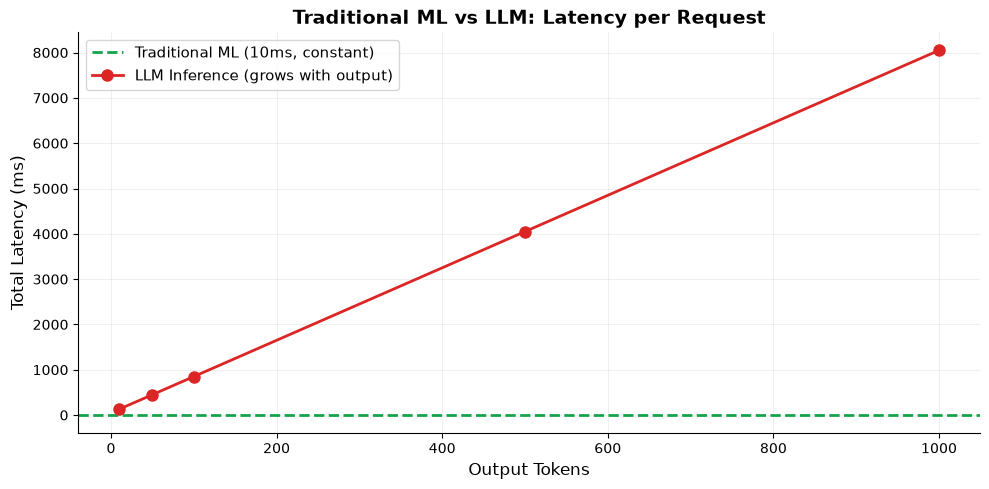


100-token response: LLM is 85x slower than traditional ML
1000-token response: LLM is 805x slower than traditional ML


In [8]:
# --- Cost per request comparison ---
# Traditional ML: 1 forward pass, ~10ms on GPU
# LLM: prefill + N decode steps

trad_ms = 10  # one forward pass
llm_prefill_ms = 50  # 500 token prompt
llm_itl_ms = 8  # per token decode
output_tokens = [10, 50, 100, 500, 1000]

# Create figure and axes for the chart
fig_2, ax_2 = plt.subplots(figsize=(10, 5))

# Traditional ML: flat line
ax_2.axhline(y=trad_ms, color="#16a34a", linewidth=2, linestyle="--",
           label=f"Traditional ML ({trad_ms}ms, constant)")

# LLM: grows with output length
llm_times = [llm_prefill_ms + t * llm_itl_ms for t in output_tokens]
ax_2.plot(output_tokens, llm_times, "o-", color="#dc2626", linewidth=2,
        markersize=8, label="LLM Inference (grows with output)")

# Label the horizontal axis
ax_2.set_xlabel("Output Tokens", fontsize=12)
# Label the vertical axis
ax_2.set_ylabel("Total Latency (ms)", fontsize=12)
# Set the chart title
ax_2.set_title("Traditional ML vs LLM: Latency per Request", fontsize=14, fontweight="bold")
# Show the legend identifying each data series
ax_2.legend(fontsize=11)
# Add grid lines for easier reading
ax_2.grid(True, alpha=0.2)
ax_2.spines["top"].set_visible(False)
ax_2.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# Display results to the notebook output
print()
# Display results to the notebook output
print(f"100-token response: LLM is {llm_times[2]/trad_ms:.0f}x slower than traditional ML")
# Display results to the notebook output
print(f"1000-token response: LLM is {llm_times[4]/trad_ms:.0f}x slower than traditional ML")

## Cost at Scale: Inference Dominates

In [9]:
# --- Monthly cost comparison ---
# Assumptions: 1M requests/day, GPU cost ~/hr (A100)
requests_per_day = 1_000_000

# Traditional ML: 10ms per request
trad_gpu_seconds_per_day = requests_per_day * 0.01  # 10ms = 0.01s
trad_gpu_hours = trad_gpu_seconds_per_day / 3600
trad_monthly = trad_gpu_hours * 30 * 2  # /hr

# LLM (200 token avg output): 50ms + 200*8ms = 1650ms per request
llm_gpu_seconds_per_day = requests_per_day * 1.65  # 1650ms = 1.65s
llm_gpu_hours = llm_gpu_seconds_per_day / 3600
llm_monthly = llm_gpu_hours * 30 * 2  # /hr

# Display results to the notebook output
print("Monthly GPU cost at 1M requests/day:")
# Display results to the notebook output
print(f"  Traditional ML:  /month")
# Display results to the notebook output
print(f"  LLM (200 tok):   /month")
# Display results to the notebook output
print(f"  Ratio:           {llm_monthly/trad_monthly:.0f}x more expensive")
# Display results to the notebook output
print(f"This is why every chapter in this book exists: to reduce that .")

Monthly GPU cost at 1M requests/day:
  Traditional ML:  /month
  LLM (200 tok):   /month
  Ratio:           165x more expensive
This is why every chapter in this book exists: to reduce that .


## Key Takeaway

LLM inference is 100-165x more expensive than traditional ML at the same request volume. The cost comes from:
1. Reading all model weights every token (bandwidth wall)
2. Generating tokens sequentially (cannot parallelize)
3. Growing KV cache consuming GPU memory (limits batch size)

The rest of this book systematically attacks each of these costs.